# Perfil de cada variable por sí sola

## Qué responde este notebook

[`2.1_eda_targets.ipynb`](2.1_eda_targets.ipynb) mostró la forma de los tres resultados. Antes de ver
cómo se relacionan las variables entre sí y con los resultados (notebooks 2.3 a 2.5), aquí se
describe cada variable por sí sola: si es simétrica o sesgada, si tiene colas largas y si sus valores
extremos son reales o errores. Se usan las semanas con al menos un pase dirigido (`targets > 0`) de
2024-2025. Las variables se definen en el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md).

**Las tres medidas que se usan:**

- **Asimetría** (*skewness*): 0 = simétrica; positiva = cola larga hacia la derecha (pocos valores
  muy altos). Cuanto más lejos de 0, más sesgada.
- **Curtosis** (en exceso): qué tan pesadas son las colas comparadas con una normal, que vale 0.
  Valores altos indican valores extremos más frecuentes de lo que una normal predice.
- **% de atípicos (regla IQR)**: valores fuera de 1.5 veces el rango intercuartil. Es el criterio
  estándar, pero no siempre aplica bien, como se ve en la sección 4.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
from scipy import stats as sstats
import matplotlib.pyplot as plt
import seaborn as sns

import data, features

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SEASONS = [2024, 2025]
stats_df = data.cargar_stats_semanales(SEASONS)
wr = stats_df[(stats_df["position"] == "WR") & (stats_df["targets"] > 0)].copy()
jugadores = data.cargar_jugadores()
calendario = data.cargar_calendario(SEASONS)

wr_ctx = wr.merge(
    jugadores[["gsis_id", "birth_date", "rookie_season", "draft_pick", "height", "weight"]],
    left_on="player_id", right_on="gsis_id", how="left"
)
ref = pd.to_datetime(wr_ctx["season"].astype(str) + "-09-01")
wr_ctx["edad"] = (ref - wr_ctx["birth_date"]).dt.days / 365.25
wr_ctx["anios_experiencia"] = wr_ctx["season"] - wr_ctx["rookie_season"]

cal_home = calendario[["season", "week", "home_team", "home_rest"]].rename(columns={"home_team": "team", "home_rest": "rest"})
cal_away = calendario[["season", "week", "away_team", "away_rest"]].rename(columns={"away_team": "team", "away_rest": "rest"})
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)
wr_ctx = wr_ctx.merge(cal_long, on=["season", "week", "team"], how="left")

of_semana = wr.groupby(["season", "team", "week"])["receiving_yards"].sum().reset_index()
of_semana["ofensiva_equipo_wr"] = of_semana.groupby(["season", "team"])["receiving_yards"].transform(lambda s: s.shift(1).expanding().mean())
wr_ctx = wr_ctx.merge(of_semana[["season", "team", "week", "ofensiva_equipo_wr"]], on=["season", "team", "week"], how="left")

RAW_COLS = [
    "receptions", "targets", "receiving_yards", "receiving_tds", "receiving_air_yards",
    "receiving_yards_after_catch", "receiving_first_downs", "receiving_epa", "racr",
    "target_share", "air_yards_share", "wopr", "receiving_20", "receiving_40",
    "carries", "rushing_yards", "fantasy_points_ppr",
]
CONTEXT_COLS = ["edad", "anios_experiencia", "draft_pick", "height", "weight", "rest", "ofensiva_equipo_wr"]
con_feats = features.agregar_promedios_jugador(wr_ctx, RAW_COLS, id_col="player_id")

def perfil(serie, nombre):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lim_bajo, lim_alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((s < lim_bajo) | (s > lim_alto)).mean() * 100
    return {"variable": nombre, "%nulo": round(serie.isna().mean() * 100, 1), "%cero": round((s == 0).mean() * 100, 1),
            "media": round(s.mean(), 2), "mediana": round(s.median(), 2), "std": round(s.std(), 2),
            "min": round(s.min(), 2), "max": round(s.max(), 2),
            "asimetria": round(sstats.skew(s), 2), "curtosis": round(sstats.kurtosis(s), 2),
            "%outliers_iqr": round(outliers, 2)}

print("listo")

listo


## 1. Las variables de rendimiento, con el valor de la semana

Primero el valor tal como ocurrió esa semana, no la versión rezagada (el promedio de semanas
anteriores, que es la que usaría un modelo; sección 3).

In [2]:
tabla_cruda = pd.DataFrame([perfil(wr_ctx[c], c) for c in RAW_COLS]).set_index("variable")
tabla_cruda.sort_values("asimetria", ascending=False)

,%nulo,%cero,media,mediana,std,min,max,asimetria,curtosis,%outliers_iqr
variable,,,,,,,,,,
racr,0.1,14.6,0.95,0.74,1.59,-2.00,43.00,12.19,241.49,5.05
rushing_yards,0.0,87.5,0.89,0.00,3.80,-12.00,65.00,5.63,47.99,12.47
carries,0.0,86.9,0.17,0.00,0.52,0.00,8.00,4.24,27.69,13.06
receiving_40,0.0,91.5,0.09,0.00,0.31,0.00,3.00,3.58,14.04,8.48
receiving_yards_after_catch,0.0,20.9,12.81,8.00,15.92,-23.00,124.00,2.09,5.62,5.97
receiving_tds,0.0,79.1,0.24,0.00,0.50,0.00,3.00,2.08,4.15,20.95
receiving_20,0.0,61.5,0.53,0.00,0.78,0.00,5.00,1.68,3.12,2.89
fantasy_points_ppr,0.0,9.5,8.33,6.10,7.60,-3.00,55.40,1.33,2.02,2.65
receiving_yards,0.0,10.8,37.48,28.00,35.26,-13.00,264.00,1.31,1.96,2.39


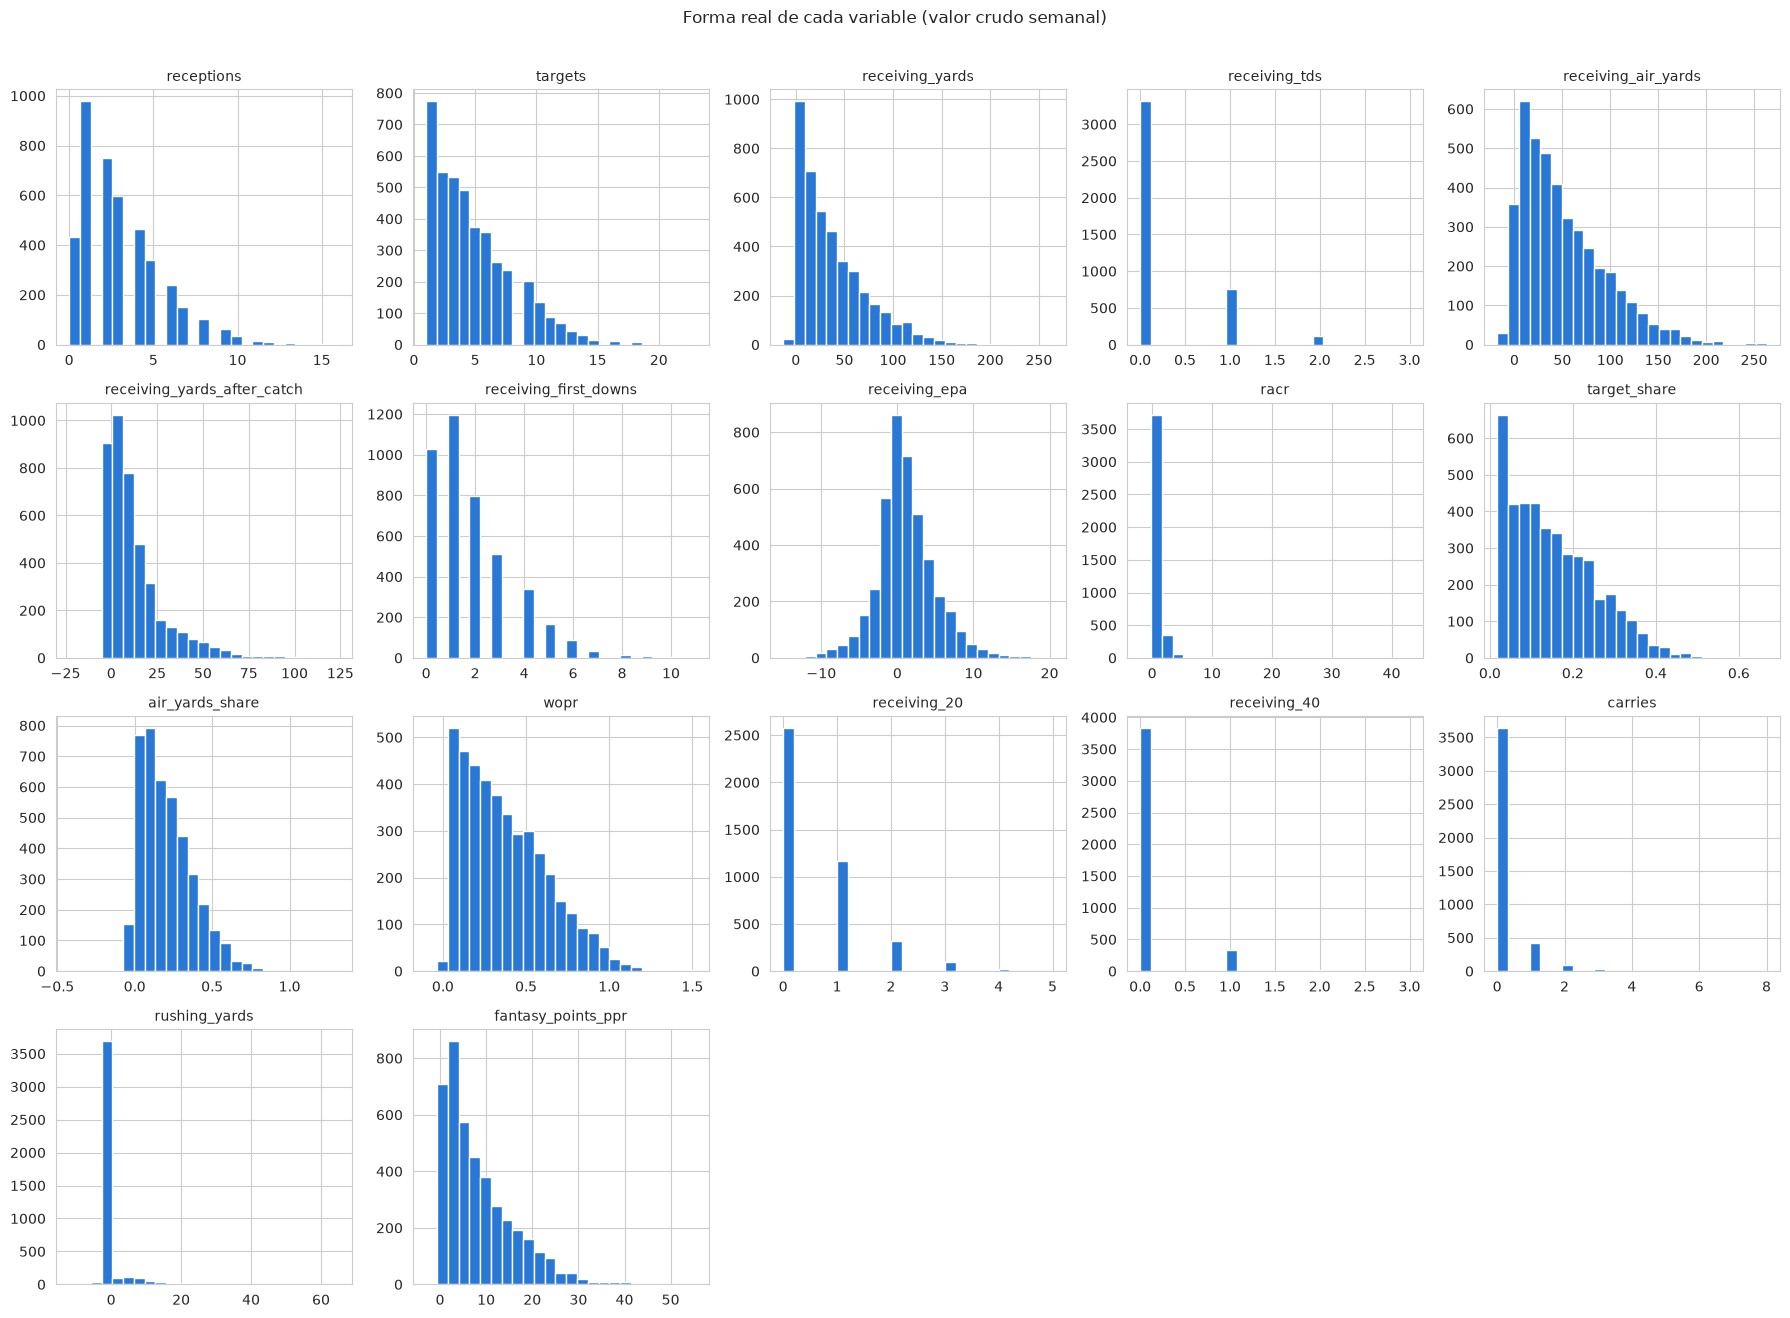

In [3]:
fig, axes = plt.subplots(4, 5, figsize=(18, 13))
for ax, col in zip(axes.flat, RAW_COLS):
    ax.hist(wr_ctx[col].dropna(), bins=25, color=AZUL, edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(RAW_COLS):]:
    ax.axis("off")
plt.suptitle("Forma real de cada variable (valor crudo semanal)", y=1.01)
plt.tight_layout()
plt.show()

**Lectura, agrupando por comportamiento:**

- **Poco sesgadas** (asimetría de 0.37 a 1.03): `receiving_epa`, `wopr`, `target_share`,
  `air_yards_share` y `targets`.
- **Sesgadas a la derecha, de forma moderada** (1.11 a 1.33): `receiving_air_yards`, `receptions`,
  `receiving_first_downs`, `receiving_yards` y `fantasy_points_ppr`. Es la forma habitual de una
  producción deportiva: muchas semanas modestas y pocas muy altas.
- **Sesgo fuerte** (1.68 a 3.58): `receiving_20` (61.5% de semanas en cero), `receiving_tds` (79.1%),
  `receiving_yards_after_catch` y `receiving_40` (91.5%).
- **Casi todo en cero** (4.24 y 5.63): `carries` y `rushing_yards`, en cero cerca del 87% de las
  semanas, porque un receptor rara vez corre con el balón. Su relación con los resultados se revisa
  en [`2.5_eda_multivariable.ipynb`](2.5_eda_multivariable.ipynb).
- **`racr`, un caso aparte**: asimetría de 12.2 y curtosis de 241, muy por encima del resto. Se
  revisa en la sección 2.

Para los modelos de árboles, el sesgo de una variable de entrada no importa: dividen por umbrales, y
cualquier transformación que conserve el orden da el mismo resultado. Para los modelos lineales sí
importa, porque los valores extremos pesan de más.

## 2. Por qué `racr` es numéricamente inestable, con el caso más extremo

In [4]:
caso = wr_ctx.nlargest(1, "racr").iloc[0]
print(caso[["player_display_name", "season", "week", "receiving_yards", "receiving_air_yards", "racr"]])

player_display_name    Khalil Shakir
season                          2025
week                               9
receiving_yards                   43
receiving_air_yards                1
racr                            43.0
Name: 3076, dtype: object


`racr` = `receiving_yards` / `receiving_air_yards`. En el caso extremo, Khalil Shakir (semana 9 de
2025), el balón viajó 1 yarda en el aire y él terminó con 43 yardas: el cociente vale 43. No es un
error de captura: cuando las yardas aéreas se acercan a cero, el cociente se dispara por
construcción. Por eso no debe entrar crudo a un modelo lineal: necesita un tope o excluirse.
[`3.1_ingenieria_features.ipynb`](3.1_ingenieria_features.ipynb) construye una versión con tope.

## 3. ¿Promediar las semanas anteriores reduce el sesgo?

El mismo perfil, ahora sobre `_season_avg`: el promedio de la temporada hasta la semana anterior
(ver [`1.4_promedios_sin_fuga.ipynb`](1.4_promedios_sin_fuga.ipynb)), que es la versión que vería
un modelo.

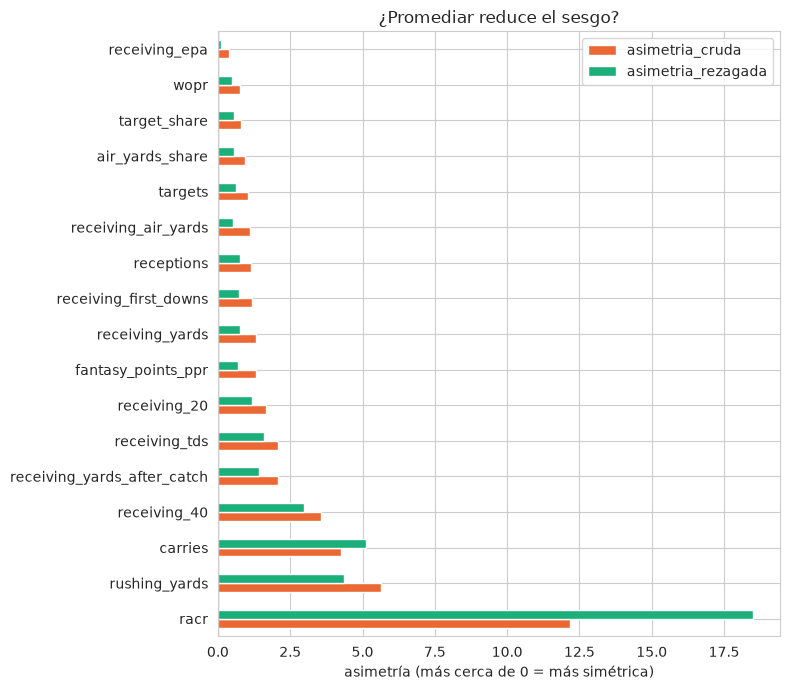

In [5]:
tabla_rezagada = pd.DataFrame([perfil(con_feats[f"{c}_season_avg"], f"{c}_season_avg") for c in RAW_COLS]).set_index("variable")

comparacion = pd.DataFrame({
    "asimetria_cruda": tabla_cruda["asimetria"].values,
    "asimetria_rezagada": tabla_rezagada["asimetria"].values,
}, index=RAW_COLS).sort_values("asimetria_cruda", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
comparacion.plot(kind="barh", ax=ax, color=[NARANJA, VERDE])
ax.set_xlabel("asimetría (más cerca de 0 = más simétrica)")
ax.set_title("¿Promediar reduce el sesgo?")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Para casi todas, sí**: promediar varias semanas reduce la asimetría (en las variables de uso y de
producción, la barra verde queda por debajo de la naranja). Hay tres excepciones. En `racr` la
asimetría sube, de 12.2 a más de 18: un solo valor disparado arrastra el promedio de toda la
temporada del jugador. En `carries` también sube un poco, y en `rushing_yards` baja pero sigue por
encima de 4: promediar semanas casi siempre en cero sigue dando valores casi siempre en cero.

## 4. Las variables de contexto

Edad, años de experiencia, posición en el draft, estatura, peso, días de descanso (`rest`) y un
promedio de la ofensiva del equipo (`ofensiva_equipo_wr`: las yardas por semana de sus receptores en
lo que va de la temporada, hasta la semana anterior).

In [6]:
tabla_contexto = pd.DataFrame([perfil(wr_ctx[c], c) for c in CONTEXT_COLS]).set_index("variable")
tabla_contexto

,%nulo,%cero,media,mediana,std,min,max,asimetria,curtosis,%outliers_iqr
variable,,,,,,,,,,
edad,0.0,0.0,26.19,25.5,2.98,21.1,35.03,0.61,-0.45,0.33
anios_experiencia,0.0,15.4,3.59,3.0,3.03,0.0,12.00,0.79,-0.17,0.00
draft_pick,15.7,0.0,85.01,63.0,68.11,4.0,258.00,0.78,-0.64,0.00
height,0.0,0.0,72.63,73.0,2.37,67.0,78.00,-0.30,-0.50,0.00
weight,0.0,0.0,199.18,200.0,15.98,155.0,235.00,-0.31,-0.32,0.00
rest,0.0,0.0,7.42,7.0,2.04,4.0,15.00,1.71,3.90,37.19
ofensiva_equipo_wr,5.9,0.0,144.57,145.6,32.28,42.5,266.00,0.08,0.43,1.73


**Lectura.** `edad` y `draft_pick` se comportan bien (asimetría de 0.61 y 0.78). `draft_pick` falta
en 15.7% de las filas: receptores que no fueron seleccionados en el draft (en
[`3.1_ingenieria_features.ipynb`](3.1_ingenieria_features.ipynb) se les asigna un valor).
`ofensiva_equipo_wr` falta en 5.9%: la primera semana de cada equipo en cada temporada, que no tiene
semanas anteriores que promediar.

**`rest` tiene 37% de «atípicos» según la regla IQR, pero no son errores.** La mayoría de los
partidos se juega con 7 días de descanso (la mediana), así que el rango intercuartil es angosto, y
cualquier otro valor (4 días por un partido de jueves, 13 o más por una semana de descanso) queda
fuera casi por definición. Pasa lo mismo con `receiving_tds` en la sección 1 (21% de «atípicos»):
con 79% de semanas en cero, el rango intercuartil vale 0 y cualquier touchdown cuenta como atípico.
Cuando una variable tiene un valor dominante, la regla IQR marca lo que no es el valor más común, no
lo que es raro o erróneo.

## Cierre

| Comportamiento | Variables | Implicación |
|---|---|---|
| Poco sesgadas | `receiving_epa`, `wopr`, `target_share`, `air_yards_share`, `targets` | Se pueden usar tal cual |
| Sesgo moderado, forma de producción | `receiving_air_yards`, `receptions`, `receiving_first_downs`, `receiving_yards`, `fantasy_points_ppr` | Tal cual en árboles; en lineales conviene escalar y revisar extremos |
| Sesgo fuerte, muchos ceros | `receiving_20`, `receiving_40`, `receiving_tds`, `receiving_yards_after_catch` | Lo mismo; promediar las semanas anteriores reduce el sesgo |
| Casi todo en cero | `carries`, `rushing_yards` | Promediar no lo corrige; su aporte se evalúa en 2.5 y en 3.2 |
| Numéricamente inestable | `racr` | Tope o exclusión antes de un modelo lineal (3.1) |
| «Atípicos» que no lo son | `receiving_tds`, `rest` | La regla IQR no aplica cuando hay un valor dominante |

Anterior: [`2.1_eda_targets.ipynb`](2.1_eda_targets.ipynb) · Siguiente:
[`2.3_eda_general.ipynb`](2.3_eda_general.ipynb)